In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
matches = pd.read_csv('/Users/tliu/Desktop/Erdos Project/1_Match_Data/matches.csv')

In [3]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115630 entries, 0 to 115629
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   player1        115630 non-null  object
 1   player2        115630 non-null  object
 2   score1         115630 non-null  int64 
 3   score2         115630 non-null  int64 
 4   best_of        115630 non-null  int64 
 5   tournament_id  115630 non-null  int64 
 6   date           39002 non-null   object
 7   year           115630 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 7.1+ MB


In [4]:
from elo_v4 import elo_rating
elo = elo_rating()
elo.update_stats(matches)
stats = elo.stats

In [5]:
stats.head()

,elo_rating,matches_played,matches_won,matches_win_rate,frames_played,frames_won,frames_win_rate
A Barrett,996,1,0,0.000,5,2,0.400000
A Bulajiang,1010,8,1,0.125,48,17,0.354167
A Chan,995,2,1,0.500,9,4,0.444444
A Coleman,992,1,0,0.000,6,2,0.333333
A Noad,988,1,0,0.000,3,0,0.000000


In [6]:
stats.sort_values(by = 'elo_rating', ascending=False, inplace=True)

Text(0, 0.5, 'Elo Rating')

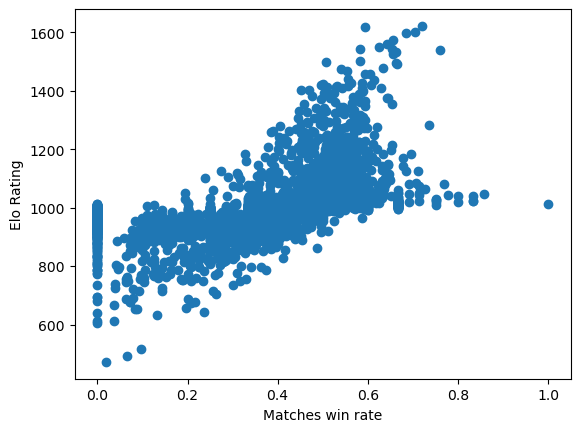

In [7]:
#Make a scatter plot of elo_rating against matches_win_rate
plt.scatter(stats.matches_win_rate, stats.elo_rating)
plt.xlabel('Matches win rate')
plt.ylabel('Elo Rating')

Text(0, 0.5, 'Elo Rating')

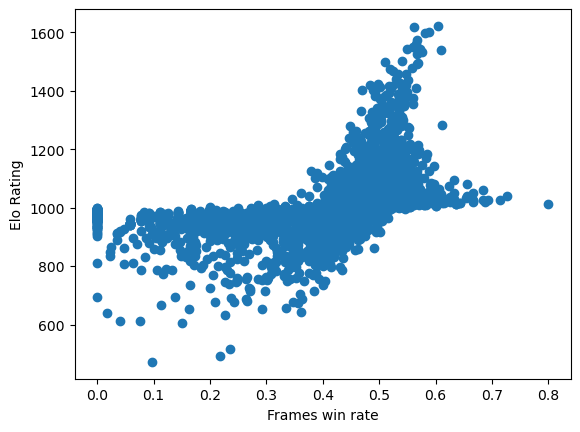

In [8]:
#Make a scatter plot of elo_rating against frames_win_rate
plt.scatter(stats.frames_win_rate, stats.elo_rating)
plt.xlabel('Frames win rate')
plt.ylabel('Elo Rating')

The first plot shows a positve correlation and might indicate a linear relation for certain subsets of data.  

In the second plot, lots of data concentrated at elo_rating=1000.

***

In [9]:
#Now we only consider the players who played more than 100 matches.
stats_100 = stats[stats['matches_played']>100]

Text(0, 0.5, 'Elo Rating')

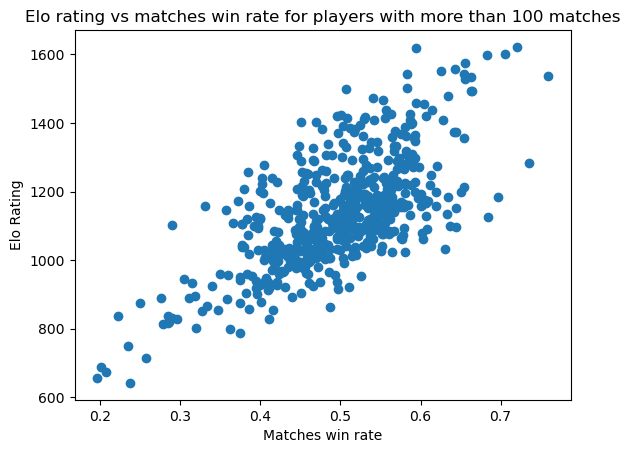

In [10]:
plt.scatter(stats_100.matches_win_rate, stats_100.elo_rating)
plt.title('Elo rating vs matches win rate for players with more than 100 matches')
plt.xlabel('Matches win rate')
plt.ylabel('Elo Rating')

Text(0, 0.5, 'Elo Rating')

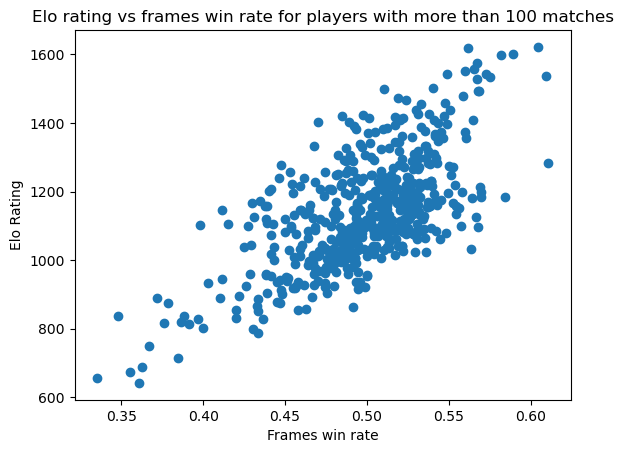

In [11]:
plt.scatter(stats_100.frames_win_rate, stats_100.elo_rating)
plt.title('Elo rating vs frames win rate for players with more than 100 matches')
plt.xlabel('Frames win rate')
plt.ylabel('Elo Rating')

There seems to be a linear relation between elo rating and frames win rate or matches win rate.